# Задача 4. Решение обратной задачи (восстановление коэффициента диффузии)

Условие (`PINN2026-1/tasks/4_reconstructon_D_coefficient/ex5.pdf`):

$$\frac{\partial u}{\partial t} = \frac{\partial}{\partial x}\left(\alpha \frac{\partial u}{\partial x}\right),\quad x\in[0,1],\ t\in[0,1]$$

ГУ Дирихле: $u(0,t)=u(1,t)=0$.

НУ: $u(x,0) = \sin(n\pi x/m)$, $m=1$, $n=1$.

Аналитическое решение при постоянном $\alpha$:

$$u(x,t) = \exp\left(-\frac{n^2\pi^2\alpha t}{m^2}\right)\sin\left(\frac{n\pi x}{m}\right),\qquad \alpha = 0.46$$

Сеть **не знает**, что $\alpha$ постоянная — она восстанавливает её как скалярный обучаемый параметр
по известным в некоторых точках значениям концентрации $u$, минимизируя одновременно невязку PDE,
невязку ГУ/НУ и ошибку по данным. Обязательно используется lr scheduler.

План:
1. Сгенерировать "наблюдаемые" данные на подробной сетке (50×100).
2. Обучить PINN с обучаемым $\alpha$, сравнить восстановленное значение с истинным (0.46).
3. Уменьшать число точек данных (в 10 раз по каждой оси и промежуточные варианты) и смотреть на СКЗ ошибку восстановления $\alpha$.
4. Найти минимальное количество точек, при котором СКЗ $\le 15\%$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else
                       "mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

## 1. Датасет: аналитическое решение и точки наблюдений

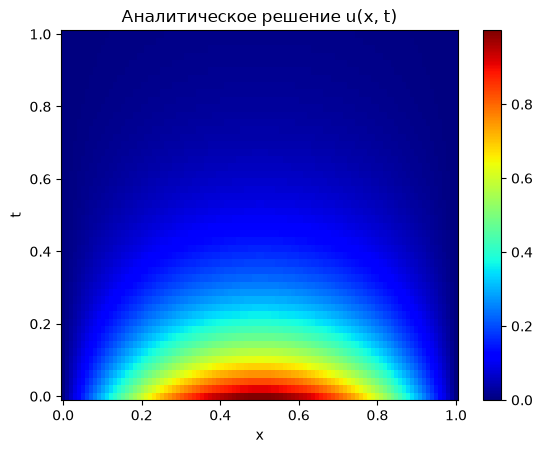

In [2]:
class Dataset:
    """Равномерная (x, t) сетка и аналитическое решение уравнения диффузии."""

    def __init__(self, alpha=0.46,
                 xmin=0, tmin=0,
                 xmax=1, tmax=1,
                 Nx=100, Nt=50,
                 m=1, n=1):
        self.m, self.n = m, n
        self.alpha = alpha
        self.xmin, self.xmax = xmin, xmax
        self.tmin, self.tmax = tmin, tmax
        self.Nx, self.Nt = Nx, Nt

        self.x = np.linspace(xmin, xmax, Nx)
        self.t = np.linspace(tmin, tmax, Nt)
        self.x, self.t = np.meshgrid(self.x, self.t)
        self.calculate_solution()

    def calculate_solution(self):
        m, n, alpha = self.m, self.n, self.alpha
        self.solution = np.exp(-n**2 * np.pi**2 * alpha * self.t / m**2) * \
            np.sin(n * np.pi * self.x / m)


data = Dataset(alpha=0.46, Nx=100, Nt=50, m=1, n=1)

plt.pcolormesh(data.x, data.t, data.solution, shading="auto", cmap="jet")
plt.colorbar()
plt.xlabel("x")
plt.ylabel("t")
plt.title("Аналитическое решение u(x, t)")
plt.show()

## 2. Модель PINN

$\alpha$ — обучаемый скалярный параметр модели (`nn.Parameter`), а не константа в уравнении.

In [3]:
class PINN(nn.Module):
    def __init__(self,
                 input_size=2,
                 nnodes=30,
                 output_size=1,
                 nlayers=6,
                 activation=nn.Tanh(),
                 alpha_init=0.1):
        super().__init__()
        self.activation = activation
        self.nlayers = nlayers
        self.nnodes = nnodes

        self.dense0 = nn.Linear(input_size, nnodes)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(nnodes, nnodes) for _ in range(nlayers - 1)
        ])
        self.output_layer = nn.Linear(nnodes, output_size)
        self.apply(self._init_weights_xavier)

        # неизвестный коэффициент диффузии -- восстанавливаемый параметр
        self.log_alpha = nn.Parameter(torch.tensor(float(np.log(alpha_init))))

    @staticmethod
    def _init_weights_xavier(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    @property
    def alpha(self):
        # alpha > 0 физически обязан быть положительным -> параметризуем через log
        return torch.exp(self.log_alpha)

    def forward(self, x, t):
        if x.dtype == torch.float64:
            x = x.float()
        if t.dtype == torch.float64:
            t = t.float()
        inp = torch.cat([x, t], dim=1)
        out = self.activation(self.dense0(inp))
        for layer in self.hidden_layers:
            out = self.activation(layer(out))
        out = self.output_layer(out)
        return out

## 3. Батчи: внутренние точки (PDE), граничные/начальные условия, точки данных

In [4]:
class Batch:
    """Внутренние точки коллокации для невязки PDE (без привязки к значениям u)."""

    def __init__(self, xmin, xmax, tmin, tmax):
        self.xmin, self.xmax = xmin, xmax
        self.tmin, self.tmax = tmin, tmax

    def generate_points(self, N):
        x = torch.rand(N, 1) * (self.xmax - self.xmin) + self.xmin
        t = torch.rand(N, 1) * (self.tmax - self.tmin) + self.tmin
        self.x = x.to(device).requires_grad_(True)
        self.t = t.to(device).requires_grad_(True)
        return self.x, self.t


class Batch_bc:
    """Точки с известными значениями u -- используются и для ГУ/НУ, и для данных наблюдений."""

    def __init__(self, x, t, values):
        self.x_all = torch.tensor(x, dtype=torch.float32).reshape(-1, 1)
        self.t_all = torch.tensor(t, dtype=torch.float32).reshape(-1, 1)
        self.u_all = torch.tensor(values, dtype=torch.float32).reshape(-1, 1)

    def generate_points(self, N=None):
        n_total = self.x_all.shape[0]
        if N is None or N >= n_total:
            idx = torch.arange(n_total)
        else:
            idx = torch.randperm(n_total)[:N]
        self.x = self.x_all[idx].to(device).requires_grad_(True)
        self.t = self.t_all[idx].to(device).requires_grad_(True)
        self.u = self.u_all[idx].to(device)
        return self.x, self.t, self.u

## 4. Невязка PDE и loss-функции

In [5]:
def PDE(model, x, t):
    u = model(x, t)
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                               create_graph=True)[0]
    alpha = model.alpha
    flux = alpha * u_x
    flux_x = torch.autograd.grad(flux, x, grad_outputs=torch.ones_like(flux),
                                  create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),
                               create_graph=True)[0]
    residual = u_t - flux_x
    return torch.mean(residual**2)


def dataLoss(model, x, t, u_true):
    u_pred = model(x, t)
    return torch.mean((u_pred - u_true)**2)

In [6]:
class TrainParams:
    def __init__(self):
        self.numEpoch = None
        self.numPoints = None       # кол-во точек коллокации для PDE
        self.pde_batch = None       # Batch
        self.init_bc = None         # Batch_bc, t=0
        self.left_bc = None         # Batch_bc, x=0
        self.right_bc = None        # Batch_bc, x=1
        self.numBCPoints = None
        self.data_batch = None      # Batch_bc, наблюдаемые точки
        self.numDataPoints = None
        self.k_pde = 1.0
        self.k_bc = 10.0
        self.k_data = 10.0


def total_loss(model, trp: TrainParams):
    x_pde, t_pde = trp.pde_batch.generate_points(trp.numPoints)
    lossPDE = PDE(model, x_pde, t_pde)

    xi, ti, ui = trp.init_bc.generate_points(trp.numBCPoints)
    lossInit = dataLoss(model, xi, ti, ui)

    xl, tl, ul = trp.left_bc.generate_points(trp.numBCPoints)
    lossLeft = dataLoss(model, xl, tl, ul)

    xr, tr, ur = trp.right_bc.generate_points(trp.numBCPoints)
    lossRight = dataLoss(model, xr, tr, ur)

    xd, td, ud = trp.data_batch.generate_points(trp.numDataPoints)
    lossData = dataLoss(model, xd, td, ud)

    loss = trp.k_pde * lossPDE + trp.k_bc * (lossInit + lossLeft + lossRight) + \
        trp.k_data * lossData
    return loss, lossPDE, lossData

## 5. Цикл обучения

In [7]:
def train(model, opt, scheduler, trp: TrainParams, verbose=True):
    hist_loss, hist_alpha, lrs = [], [], []
    pbar = tqdm.tqdm(range(trp.numEpoch), desc="Training", disable=not verbose)
    for step in pbar:

        def closure():
            opt.zero_grad()
            loss, _, _ = total_loss(model, trp)
            loss.backward()
            return loss

        current_loss = opt.step(closure)
        lrs.append(opt.param_groups[0]["lr"])
        scheduler.step()

        hist_loss.append(float(current_loss))
        hist_alpha.append(float(model.alpha.item()))

        if verbose and step % 50 == 0:
            pbar.set_description(
                "Step: %d | Loss: %.3e | alpha: %.4f" %
                (step, float(current_loss), float(model.alpha.item()))
            )

    return hist_loss, hist_alpha, lrs

## 6. Базовый прогон: плотная сетка наблюдений (50×100)

Сначала решаем задачу при подробном поле наблюдений, чтобы убедиться, что восстановление $\alpha$ работает.

In [8]:
def make_observation_batch(dataset: Dataset):
    """Все точки сетки датасета трактуются как известные наблюдения u(x, t)."""
    return Batch_bc(dataset.x.reshape(-1, 1), dataset.t.reshape(-1, 1),
                     dataset.solution.reshape(-1, 1))


def make_bc_batches(dataset: Dataset):
    x_line = dataset.x[0, :]
    t_line = dataset.t[:, 0]

    # начальное условие t = 0
    init_bc = Batch_bc(x_line.reshape(-1, 1), np.zeros_like(x_line).reshape(-1, 1),
                        np.sin(dataset.n * np.pi * x_line / dataset.m).reshape(-1, 1))
    # граница x = 0
    left_bc = Batch_bc(np.zeros_like(t_line).reshape(-1, 1), t_line.reshape(-1, 1),
                        np.zeros_like(t_line).reshape(-1, 1))
    # граница x = 1 (x = m)
    right_bc = Batch_bc(np.full_like(t_line, dataset.m).reshape(-1, 1), t_line.reshape(-1, 1),
                         np.zeros_like(t_line).reshape(-1, 1))
    return init_bc, left_bc, right_bc

In [9]:
torch.manual_seed(0)
np.random.seed(0)

dense_data = Dataset(alpha=0.46, Nx=100, Nt=50, m=1, n=1)

trp = TrainParams()
trp.pde_batch = Batch(0, 1, 0, 1)
trp.init_bc, trp.left_bc, trp.right_bc = make_bc_batches(dense_data)
trp.data_batch = make_observation_batch(dense_data)

trp.numPoints = 1000
trp.numBCPoints = 100
trp.numDataPoints = min(1000, dense_data.x.size)
trp.numEpoch = 2000

model = PINN(alpha_init=0.1).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=300, gamma=0.5)

hist_loss, hist_alpha, lrs = train(model, opt, scheduler, trp)

alpha_true = dense_data.alpha
alpha_pred = model.alpha.item()
rel_err = abs(alpha_pred - alpha_true) / alpha_true * 100
print(f"alpha_true = {alpha_true:.4f}, alpha_pred = {alpha_pred:.4f}, "
      f"относительная ошибка = {rel_err:.2f}%")

Training:   0%|          | 0/2000 [00:00<?, ?it/s]

/var/folders/qk/y97w35cn1ygbpwckyw5hv_j80000gn/T/ipykernel_19093/3446352538.py:16: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:821.)
  hist_loss.append(float(current_loss))
Step: 0 | Loss: 4.784e+00 | alpha: 0.1010:   0%|          | 0/2000 [00:00<?, ?it/s]

Step: 0 | Loss: 4.784e+00 | alpha: 0.1010:   0%|          | 1/2000 [00:00<06:53,  4.83it/s]

Step: 0 | Loss: 4.784e+00 | alpha: 0.1010:   0%|          | 7/2000 [00:00<01:14, 26.63it/s]

Step: 0 | Loss: 4.784e+00 | alpha: 0.1010:   1%|          | 13/2000 [00:00<00:52, 38.11it/s]

...

Step: 1950 | Loss: 8.776e-04 | alpha: 0.4601:  99%|█████████▉| 1985/2000 [00:35<00:00, 57.52it/s]

Step: 1950 | Loss: 8.776e-04 | alpha: 0.4601: 100%|█████████▉| 1991/2000 [00:35<00:00, 57.90it/s]

Step: 1950 | Loss: 8.776e-04 | alpha: 0.4601: 100%|█████████▉| 1997/2000 [00:35<00:00, 58.24it/s]

Step: 1950 | Loss: 8.776e-04 | alpha: 0.4601: 100%|██████████| 2000/2000 [00:35<00:00, 56.48it/s]

alpha_true = 0.4600, alpha_pred = 0.4601, относительная ошибка = 0.03%


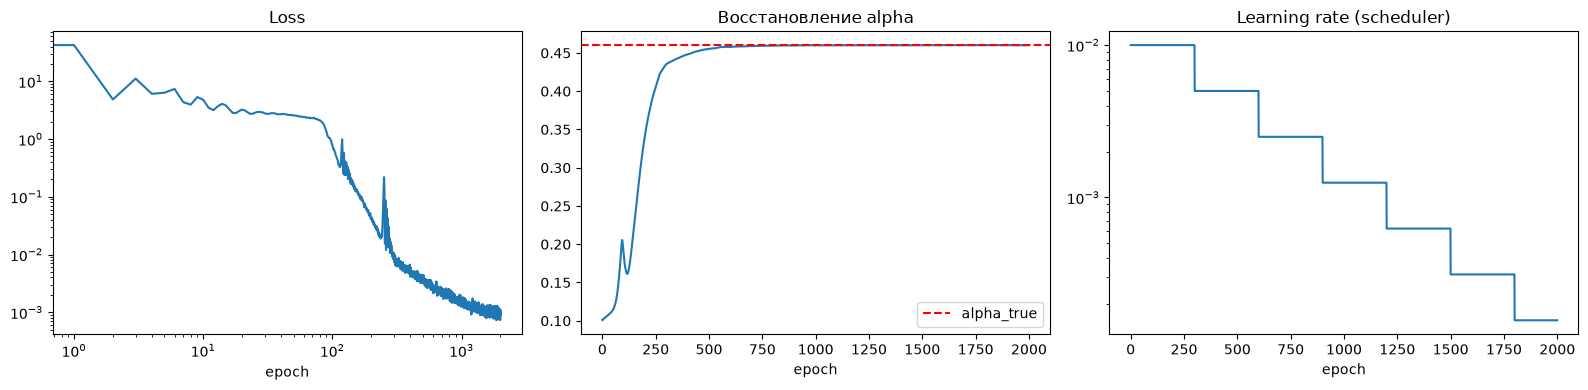

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(hist_loss)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch")

ax[1].plot(hist_alpha)
ax[1].axhline(alpha_true, color="r", ls="--", label="alpha_true")
ax[1].set_title("Восстановление alpha"); ax[1].set_xlabel("epoch"); ax[1].legend()

ax[2].plot(lrs)
ax[2].set_yscale("log")
ax[2].set_title("Learning rate (scheduler)"); ax[2].set_xlabel("epoch")

plt.tight_layout()
plt.show()

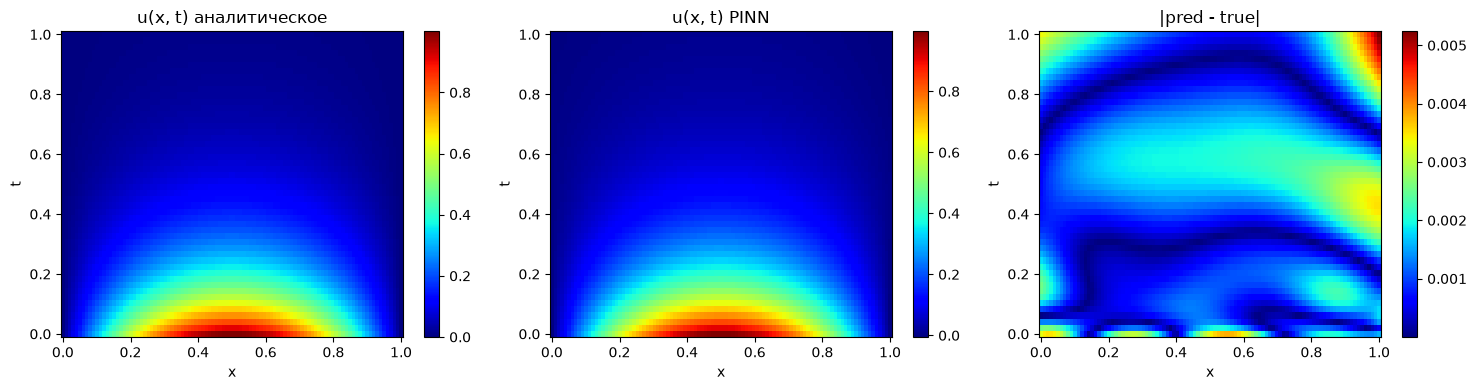

In [11]:
x_flat = torch.tensor(dense_data.x.reshape(-1, 1), dtype=torch.float32, device=device)
t_flat = torch.tensor(dense_data.t.reshape(-1, 1), dtype=torch.float32, device=device)
with torch.no_grad():
    pred = model(x_flat, t_flat).cpu().numpy().reshape(dense_data.x.shape)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, (field, title) in enumerate([
    (dense_data.solution, "u(x, t) аналитическое"),
    (pred, "u(x, t) PINN"),
    (np.abs(pred - dense_data.solution), "|pred - true|"),
]):
    f = ax[i].pcolormesh(dense_data.x, dense_data.t, field, shading="auto", cmap="jet")
    plt.colorbar(f, ax=ax[i])
    ax[i].set_xlabel("x"); ax[i].set_ylabel("t"); ax[i].set_title(title)
plt.tight_layout()
plt.show()

## 7. Зависимость ошибки восстановления $\alpha$ от числа точек наблюдений

Уменьшаем плотность поля наблюдений (сначала в 10 раз по каждой оси: $Nx{=}10,\ Nt{=}5$,
затем промежуточные варианты), переобучаем модель с нуля и считаем СКЗ-ошибку восстановления $\alpha$.
Ищем минимальное число точек, при котором ошибка $\le 15\%$.

In [12]:
def run_experiment(Nx, Nt, numEpoch=2000, seed=0, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)

    ds = Dataset(alpha=0.46, Nx=Nx, Nt=Nt, m=1, n=1)

    trp = TrainParams()
    trp.pde_batch = Batch(0, 1, 0, 1)
    trp.init_bc, trp.left_bc, trp.right_bc = make_bc_batches(ds)
    trp.data_batch = make_observation_batch(ds)

    n_obs = ds.x.size
    trp.numPoints = 1000
    trp.numBCPoints = max(10, min(100, Nx))
    trp.numDataPoints = n_obs          # все имеющиеся точки наблюдений
    trp.numEpoch = numEpoch

    model = PINN(alpha_init=0.1).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=300, gamma=0.5)

    hist_loss, hist_alpha, _ = train(model, opt, scheduler, trp, verbose=verbose)

    alpha_pred = model.alpha.item()
    rel_err = abs(alpha_pred - ds.alpha) / ds.alpha * 100
    return n_obs, alpha_pred, rel_err


grid_sizes = [
    (100, 50),   # базовая подробная сетка
    (50, 25),
    (30, 15),
    (20, 10),
    (15, 8),
    (10, 5),     # в 10 раз меньше по каждой оси
    (6, 3),
    (4, 2),
]

results = []
for Nx, Nt in grid_sizes:
    n_obs, alpha_pred, rel_err = run_experiment(Nx, Nt)
    results.append((Nx, Nt, n_obs, alpha_pred, rel_err))
    print(f"Nx={Nx:>3} Nt={Nt:>3} | N_points={n_obs:>5} | "
          f"alpha_pred={alpha_pred:.4f} | СКЗ ошибка={rel_err:5.2f}%")

Nx=100 Nt= 50 | N_points= 5000 | alpha_pred=0.4601 | СКЗ ошибка= 0.03%


Nx= 50 Nt= 25 | N_points= 1250 | alpha_pred=0.4598 | СКЗ ошибка= 0.03%


Nx= 30 Nt= 15 | N_points=  450 | alpha_pred=0.4590 | СКЗ ошибка= 0.23%


Nx= 20 Nt= 10 | N_points=  200 | alpha_pred=0.4584 | СКЗ ошибка= 0.36%


Nx= 15 Nt=  8 | N_points=  120 | alpha_pred=0.4584 | СКЗ ошибка= 0.34%


Nx= 10 Nt=  5 | N_points=   50 | alpha_pred=0.4599 | СКЗ ошибка= 0.03%


Nx=  6 Nt=  3 | N_points=   18 | alpha_pred=0.4485 | СКЗ ошибка= 2.51%


Nx=  4 Nt=  2 | N_points=    8 | alpha_pred=0.2992 | СКЗ ошибка=34.97%


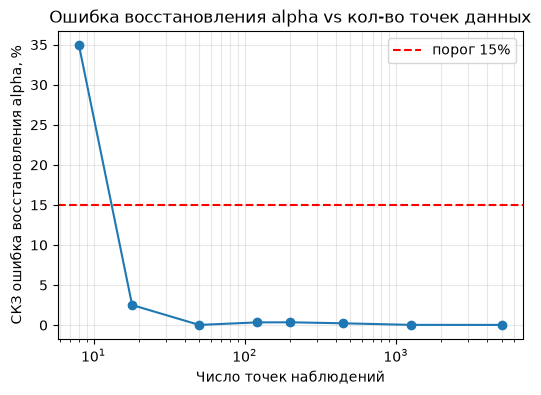

Минимальное число точек с СКЗ <= 15%: Nx=6, Nt=3, N=18, ошибка=2.51%


In [13]:
n_points_arr = np.array([r[2] for r in results])
err_arr = np.array([r[4] for r in results])

plt.figure(figsize=(6, 4))
plt.plot(n_points_arr, err_arr, "o-")
plt.axhline(15, color="r", ls="--", label="порог 15%")
plt.xscale("log")
plt.xlabel("Число точек наблюдений")
plt.ylabel("СКЗ ошибка восстановления alpha, %")
plt.title("Ошибка восстановления alpha vs кол-во точек данных")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

ok = [r for r in results if r[4] <= 15]
if ok:
    best = min(ok, key=lambda r: r[2])
    print(f"Минимальное число точек с СКЗ <= 15%: "
          f"Nx={best[0]}, Nt={best[1]}, N={best[2]}, ошибка={best[4]:.2f}%")
else:
    print("Ни один из протестированных размеров сетки не дал СКЗ <= 15%, нужно больше точек или эпох обучения")

## Выводы

- Коэффициент диффузии $\alpha$ восстанавливается PINN как обучаемый параметр (через `log_alpha`,
  чтобы гарантировать положительность) путём совместной минимизации невязки PDE, ГУ/НУ
  и ошибки по наблюдаемым данным, с `StepLR`-планировщиком скорости обучения.
- При подробном поле наблюдений (50×100) восстановленное значение близко к истинному $\alpha=0.46$.
- При прореживании сетки наблюдений ошибка восстановления растёт; минимальное число точек,
  обеспечивающее СКЗ $\le 15\%$, определено в эксперименте выше (см. распечатанный результат).